# Introduction to Computer Vision: Plant Seedlings Classification

## Problem Statement

### Context

In recent times, the field of agriculture has been in urgent need of modernizing, since the amount of manual work people need to put in to check if plants are growing correctly is still highly extensive. Despite several advances in agricultural technology, people working in the agricultural industry still need to have the ability to sort and recognize different plants and weeds, which takes a lot of time and effort in the long term. The potential is ripe for this trillion-dollar industry to be greatly impacted by technological innovations that cut down on the requirement for manual labor, and this is where Artificial Intelligence can actually benefit the workers in this field, as **the time and energy required to identify plant seedlings will be greatly shortened by the use of AI and Deep Learning.** The ability to do so far more efficiently and even more effectively than experienced manual labor, could lead to better crop yields, the freeing up of human inolvement for higher-order agricultural decision making, and in the long term will result in more sustainable environmental practices in agriculture as well.


### Objective

The aim of this project is to Build a Convolutional Neural Netowrk to classify plant seedlings into their respective categories.

### Data Dictionary

The Aarhus University Signal Processing group, in collaboration with the University of Southern Denmark, has recently released a dataset containing **images of unique plants belonging to 12 different species.**

- The dataset can be download from Olympus.
- The data file names are:
    - images.npy
    - Labels.csv
- Due to the large volume of data, the images were converted to the images.npy file and the labels are also put into Labels.csv, so that you can work on the data/project seamlessly without having to worry about the high data volume.

- The goal of the project is to create a classifier capable of determining a plant's species from an image.

**List of Species**

- Black-grass
- Charlock
- Cleavers
- Common Chickweed
- Common Wheat
- Fat Hen
- Loose Silky-bent
- Maize
- Scentless Mayweed
- Shepherds Purse
- Small-flowered Cranesbill
- Sugar beet

### **Note: Please use GPU runtime on Google Colab to execute the code faster.**

## Importing necessary libraries

In [ ]:
# Project: Convolutional Neural Networks - Image Classification               ##
# Plants image classification                                                 ##
# Submitted by "Bindu S Pillai"                                               ##
# AIML PG Program condcuted by University of Texas, Austin. Dated - 7/9/2021  ##
################################################################################
# library for creating data paths
import os

# library for randonly selecting data points
import random

# library for performing numerical computations
import numpy as np
import pandas as pd
np.random.seed(1)

# library for creating and showing plots
import matplotlib.pyplot as plt

# library for reading and showing images
import matplotlib.image as mpimg

#Filter Warnings
import warnings
warnings.filterwarnings('ignore')

# importing all the required sub-modules from keras
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.models import Sequential, Model
from keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing.image import img_to_array, load_img
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

## Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
y_data=pd.read_csv('/content/Labels.csv')
#data = np.load('/content/images.npy')

Mounted at /content/gdrive


In [ ]:
data = np.load('/content/images.npy')

In [ ]:
y_data=pd.read_csv('/content/Labels.csv')
data = np.load('/content/images.npy')

**Problem Definition and Data Overview**

In [ ]:
print(y_data)

                          Label
0     Small-flowered Cranesbill
1     Small-flowered Cranesbill
2     Small-flowered Cranesbill
3     Small-flowered Cranesbill
4     Small-flowered Cranesbill
...                         ...
4745           Loose Silky-bent
4746           Loose Silky-bent
4747           Loose Silky-bent
4748           Loose Silky-bent
4749           Loose Silky-bent

[4750 rows x 1 columns]


In [ ]:
y_data.value_counts()

,count
Label,
Loose Silky-bent,654
Common Chickweed,611
Scentless Mayweed,516
Small-flowered Cranesbill,496
Fat Hen,475
Charlock,390
Sugar beet,385
Cleavers,287
Black-grass,263


In [ ]:
print(data)

[[[[ 35  52  78]
   [ 36  49  76]
   [ 31  45  69]
   ...
   [ 78  95 114]
   [ 76  93 110]
   [ 80  95 109]]

  [[ 33  46  68]
   [ 37  50  73]
   [ 48  65  83]
   ...
   [ 81  96 113]
   [ 74  89 105]
   [ 83  95 109]]

  [[ 34  50  68]
   [ 35  52  72]
   [ 70  85 101]
   ...
   [ 83  97 112]
   [ 79  94 108]
   [ 79  94 107]]

  ...

  [[ 35  50  69]
   [ 42  57  73]
   [ 42  57  72]
   ...
   [ 60  76  92]
   [ 67  81  97]
   [ 64  77  95]]

  [[ 36  52  67]
   [ 48  63  78]
   [ 41  57  73]
   ...
   [ 44  66  83]
   [ 58  76  91]
   [ 57  74  90]]

  [[ 44  58  70]
   [ 43  57  73]
   [ 40  55  72]
   ...
   [ 41  70  92]
   [ 55  78  97]
   [ 61  79  96]]]


 [[[ 30  47  63]
   [ 30  50  60]
   [ 34  47  63]
   ...
   [ 48  59  74]
   [ 42  54  69]
   [ 44  56  70]]

  [[ 30  49  67]
   [ 26  47  60]
   [ 30  40  61]
   ...
   [ 50  64  76]
   [ 52  67  78]
   [ 45  56  72]]

  [[ 23  46  65]
   [ 27  48  64]
   [ 25  40  59]
   ...
   [ 39  59  81]
   [ 47  62  79]
   [ 42  54

**Print shape of data**

In [ ]:
data.shape

(4750, 128, 128, 3)

There are 4750 images of size 128 by 128 and 3 channels(RGB). Hence they are color images


In [ ]:
y_data.shape

(4750, 1)

In [ ]:
y= y_data['Label']

In [ ]:
y.shape

(4750,)

There are 4750 labels corresponding to the images likewise.

Displaying some labels
**bold text**

In [ ]:
print(y[0])
print(y[1000])

Small-flowered Cranesbill
Shepherds Purse


**Visualize the images**


<ul><li>Displaying some iamges from the dataset</ul></li>




Label: Small-flowered Cranesbill


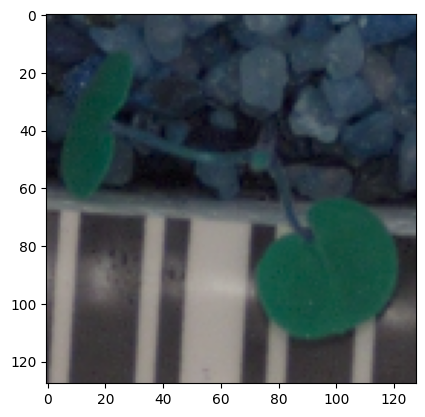

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
print("Label: {}".format(y[10]))
plt.imshow(data[10])

Label: Small-flowered Cranesbill


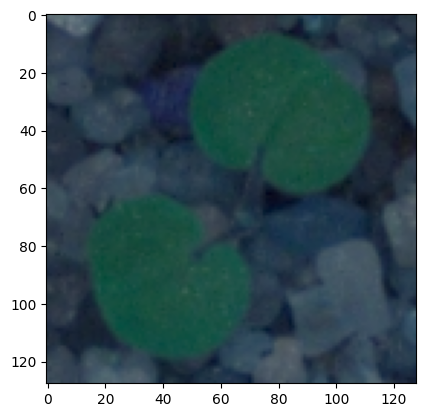

In [ ]:
print("Label: {}".format(y[200]))
plt.imshow(data[200])

Label: Fat Hen


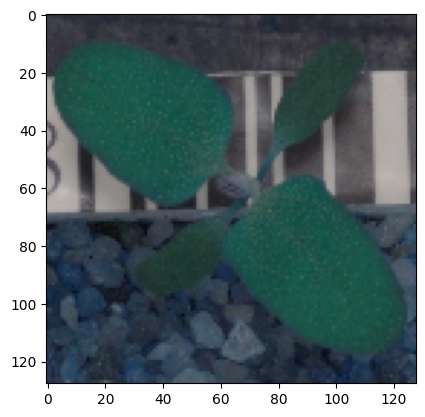

In [ ]:
print("Label: {}".format(y[500]))
plt.imshow(data[500])

Label: Shepherds Purse


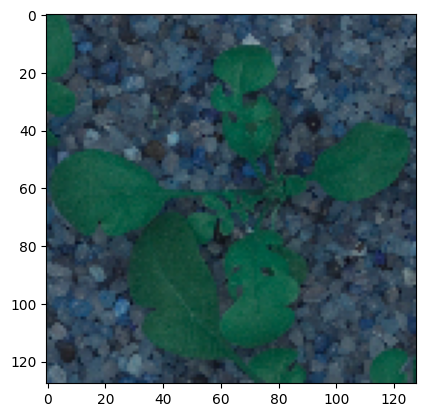

In [ ]:
print("Label: {}".format(y[1000]))
plt.imshow(data[1000],cmap= 'gray')

Label: Common Chickweed


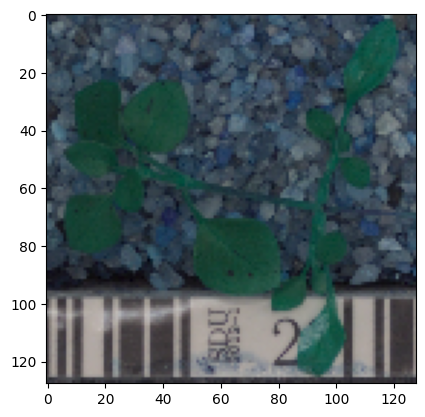

In [ ]:
print("Label: {}".format(y[1500]))
plt.imshow(data[1500])

In [ ]:
# Import necessary libraries.
import cv2
from google.colab.patches import cv2_imshow

<ul><li>Sample Image visualize before and after Gaussian blurring</ul></li>

Original Image:



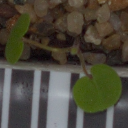


 Output after first gaussian blurring: 



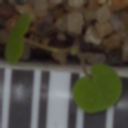


 Output after second gaussian blurring: 



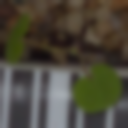

In [ ]:
Gaussian1 = cv2.GaussianBlur(data[10], (5, 5), 0)
Gaussian2 = cv2.GaussianBlur(data[10], (15, 15), 0)
print('Original Image:\n')
cv2_imshow(data[10])
print('\n Output after first gaussian blurring: \n')
cv2_imshow(Gaussian1)
print('\n Output after second gaussian blurring: \n')
cv2_imshow(Gaussian2)

**One hot-encoding of labels**


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
y=pd.get_dummies(y_data)

In [ ]:
pd. set_option("display.max_columns", None)
y.head()

,Label_Black-grass,Label_Charlock,Label_Cleavers,Label_Common Chickweed,Label_Common wheat,Label_Fat Hen,Label_Loose Silky-bent,Label_Maize,Label_Scentless Mayweed,Label_Shepherds Purse,Label_Small-flowered Cranesbill,Label_Sugar beet
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,True,False


In [ ]:
y_labels =  { 0 : 'Black-grass', 1 : 'Charlock', 2 : 'Cleavers', 3 : 'Common Chickweed', 4 : 'Common wheat', 5 : 'Fat Hen', 6 : 'Loose Silky-bent', 7 :  'Maize',
 8 : 'Scentless Mayweed', 9 : 'Shepherds Purse', 10 : 'Small-flowered Cranesbill', 11 : 'Sugar beet'}

In [ ]:
y_labels

{0: 'Black-grass',
 1: 'Charlock',
 2: 'Cleavers',
 3: 'Common Chickweed',
 4: 'Common wheat',
 5: 'Fat Hen',
 6: 'Loose Silky-bent',
 7: 'Maize',
 8: 'Scentless Mayweed',
 9: 'Shepherds Purse',
 10: 'Small-flowered Cranesbill',
 11: 'Sugar beet'}

In [ ]:
y_data.iloc[0]

,0
Label,Small-flowered Cranesbill


In [ ]:
#Selecting all columns of the encoded vector
y=y[:]

In [ ]:
type(y)

pandas.core.frame.DataFrame

In [ ]:
#Converting to numpy array.
y=y.values

In [ ]:
# Checking data type again
type(y)

numpy.ndarray

In [ ]:
type(data)

numpy.ndarray

In [ ]:
y

array([[False, False, False, ..., False,  True, False],
       [False, False, False, ..., False,  True, False],
       [False, False, False, ..., False,  True, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [ ]:
y[0]

array([False, False, False, False, False, False, False, False, False,
       False,  True, False])

**Exploratory Data Analysis**

In [ ]:
def plot_images(images,labels):
  num_classes=10                                                                  # Number of Classes
  categories=np.unique(labels)
  keys=dict(labels['Label'])                                                      # Obtaing the unique classes from y_train
  rows = 3                                                                        # Defining number of rows=3
  cols = 4                                                                        # Defining number of columns=4
  fig = plt.figure(figsize=(10, 8))                                               # Defining the figure size to 10x8
  for i in range(cols):
      for j in range(rows):
          random_index = np.random.randint(0, len(labels))                        # Generating random indices from the data and plotting the images
          ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
          ax.imshow(images[random_index, :])                                      # Plotting the image
          ax.set_title(keys[random_index])
  plt.show()

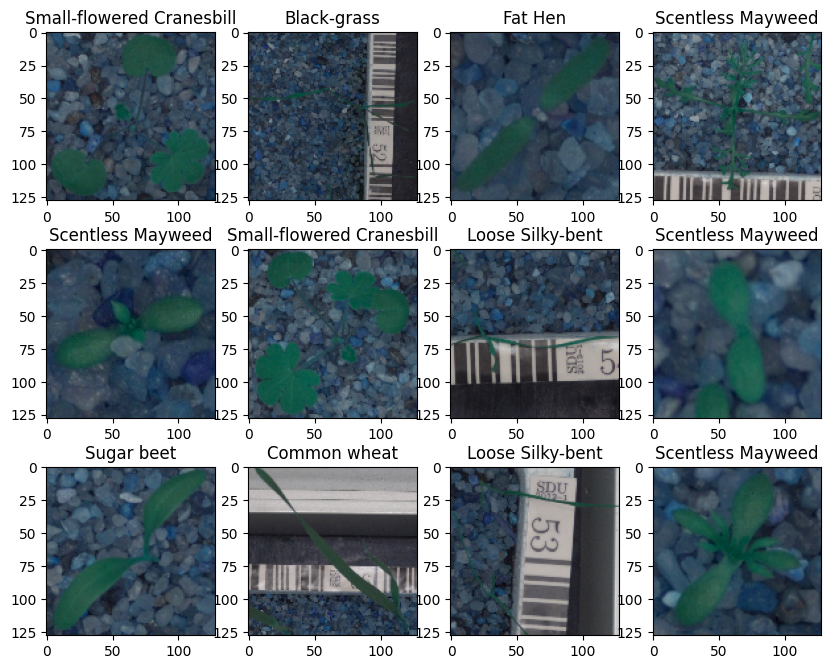

In [ ]:
plot_images(data,y_data)

**Dataset Structure**<br>
<ul><li>Input: 12 labeled plant images in a grid (4x3 layout).</ul></li>
<ul><li>Labels:<br> Represent different plant species, e.g., <br>Black-grass, <br>Fat Hen, <br>Scentless Mayweed, etc.<br>
<ul><li>Class Balance: Imbalance observed <br>(e.g., "Scentless Mayweed" appears multiple times).</ul></li>
<ul><li>Visual Features<br>
Color Contrast: Green plants stand out against the blue granular background.<br>
Shape and Structure: Leaf shapes, sizes, and orientations provide strong visual clues.<br>
Noise: Presence of measurement scales and inconsistent backgrounds could mislead the model.<br>
<ul><li>Challenges for CNN<br>
Class Overlap: Fine-grained classification is required to differentiate visually similar species.<br>
Noise: Background textures and scales might interfere with learning.<br>
Class Imbalance: Frequent labels may bias predictions toward dominant classes.<br>
Limited Dataset Size: Overfitting is a risk due to small data volume.<br></ul></li>
Recommendations
<ul><li>Preprocessing:<br>
Resize images to a standard size (e.g., 224x224).
Normalize pixel values.<br>
Remove or mask measurement scales to reduce noise.<br>
<ul><li>Data Augmentation:<br></ul></li>
Random rotations, flips, cropping, and lighting adjustments.<br>
<ul><li>Transfer Learning:<br></ul></li>
Use pretrained models (e.g., ResNet, VGG16, EfficientNet) for fine-tuning.<br>
<ul><li>Handling Imbalance:</ul></li><br>
Apply class-weighted loss or oversampling for minority classes.<br>
<ul><li>Practical Application</ul></li><br>
Ideal for multi-class classification of plant species in agriculture, weed detection, and automated plant monitoring.<br>
This dataset is well-suited for training a CNN-based image classifier, with preprocessing and augmentation playing a critical role in overcoming challenges like class imbalance, background noise, and limited data size. 🌱

0       Small-flowered Cranesbill
1       Small-flowered Cranesbill
2       Small-flowered Cranesbill
3       Small-flowered Cranesbill
4       Small-flowered Cranesbill
                  ...            
4745             Loose Silky-bent
4746             Loose Silky-bent
4747             Loose Silky-bent
4748             Loose Silky-bent
4749             Loose Silky-bent
Name: Label, Length: 4750, dtype: object


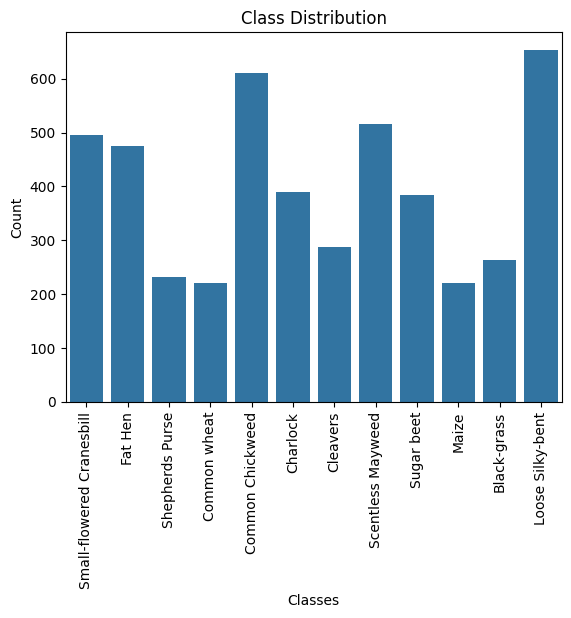

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print(y_data['Label'])

sns.countplot(x=y_data['Label'])  # Draw bars
plt.xticks(rotation='vertical')   # Rotate x-axis labels
plt.title("Class Distribution")   # Add a title
plt.xlabel("Classes")             # Add x-axis label
plt.ylabel("Count")               # Add y-axis label

plt.show()  # Display the plot

From a CNN perspective, the class imbalance seen here can significantly impact training and prediction. Addressing this imbalance through techniques like data augmentation, class weighting, and oversampling will be crucial for building a well-generalized model that performs well across all classes.








**Data Pre-processing**

**Gaussian Blurring**

In [ ]:
# Making a copy of images data to apply Gaussian blurring.
data1=data

In [ ]:
# Now we apply the gaussian blur to each 128x128 pixels array (image) to reduce the noise in the image
for idx, img in enumerate(data1):
  data1[idx] = cv2.GaussianBlur(img, (5, 5), 0)

**Split the dataset into training , testing and validation set**

In [ ]:
# Train Test split using Gaussian blurred data
X_train, X_test, y_train, y_test = train_test_split(data1, y, train_size=0.70, random_state=5)
#split test and validation using Gaussian blurred data
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size = 0.5, random_state = 5)
# Train test split using original data (not blurred)
X1_train, X1_test, y1_train, y1_test = train_test_split(data, y, train_size=0.70, random_state=5)
#split test and validation using original data (not blurred)
X1_test, X1_val, y1_test, y1_val = train_test_split(X1_test, y1_test, test_size = 0.5, random_state = 1)

**Normalize data**

In [ ]:
# Normalize the Gaussian blurred data
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
# Normalize the original data
X1_train = X1_train.astype('float32') / 255.0
X1_test = X1_test.astype('float32') / 255.0
X1_val = X1_val.astype('float32') / 255.0

**Check the shape of data, Reshape data into shapes compatible with Keras models if it’s not already.**

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(3325, 128, 128, 3)
(712, 128, 128, 3)
(713, 128, 128, 3)


In [ ]:
print(X1_train.shape)
print(X1_test.shape)
print(X1_val.shape)

(3325, 128, 128, 3)
(712, 128, 128, 3)
(713, 128, 128, 3)


In [ ]:
print(y_train.shape)
print(y_test.shape)
print(y_val.shape)

(3325, 12)
(712, 12)
(713, 12)


In [ ]:
print(y1_train.shape)
print(y1_test.shape)
print(y1_val.shape)

(3325, 12)
(712, 12)
(713, 12)


**This data is already in compatible shape to be used with CNN models. We can use 3 dimensional arrays indicating color images as input to the model. In this case the arrays are of size 128,128,3.**

**Visualize data after preprocessing**

In [ ]:
y_labels

{0: 'Black-grass',
 1: 'Charlock',
 2: 'Cleavers',
 3: 'Common Chickweed',
 4: 'Common wheat',
 5: 'Fat Hen',
 6: 'Loose Silky-bent',
 7: 'Maize',
 8: 'Scentless Mayweed',
 9: 'Shepherds Purse',
 10: 'Small-flowered Cranesbill',
 11: 'Sugar beet'}

Label: [False  True False False False False False False False False False False]


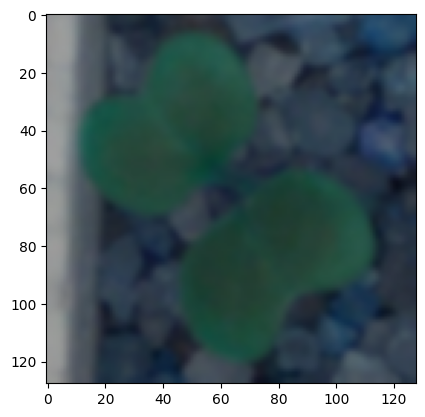

In [ ]:
print("Label: {}".format(y_train[1500]))
plt.imshow(X_train[1500])

<ul><li>From Label Array and looking at y_labels. This is a charlock.</ul></li>

Label: [False False False  True False False False False False False False False]


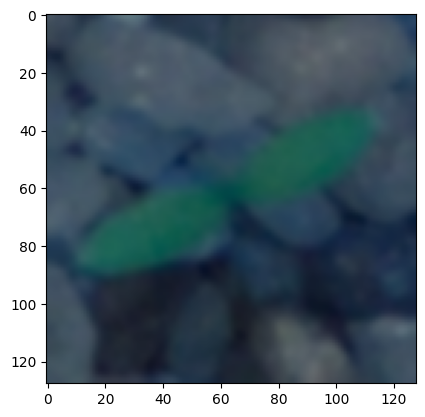

In [ ]:
print("Label: {}".format(y_train[300]))
plt.imshow(X_train[300])

<ul><li>From Label Array and looking at y_labels. This is a 'Common Chickweed'.</ul></li>

Label: [False False False False False False  True False False False False False]


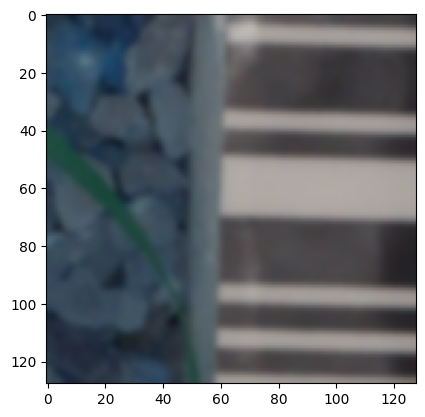

In [ ]:
print("Label: {}".format(y_train[0]))
plt.imshow(X_train[0])

<ul><li>From Label Array and looking at y_labels. This is a 'Loose Silky-bent'.</ul></li>

Label: [False False  True False False False False False False False False False]


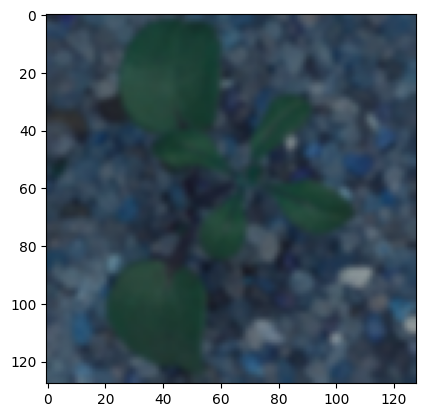

In [ ]:
print("Label: {}".format(y_train[3000]))
plt.imshow(X_train[3000])

**Print Label for Y_train[0]**

In [ ]:
print(y_train[0])

[False False False False False False  True False False False False False]


<ul><li>From Label Array and looking at y_labels. This is a 'Cleavers'.</ul></li>

**Augmenting data to reduce overfitting**

In [ ]:
import numpy as np

data = np.load('/content/images.npy')
data_generator = ImageDataGenerator(rotation_range=20,
                                    zoom_range=0.2,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    horizontal_flip=True,
                                    vertical_flip=True,
    )
data_generator.fit(X_train)
data_generator.fit(X1_train)

**Model building**

**Building CNN - Define layers of CNN, Batch Normalization, max pooling, Dropout and Dense layer(Fully Connected Network)**

In [ ]:
#@title Model 1
# Set the CNN model

#initialize the model
batch_size = None
model = models.Sequential()

#This adds the input layer (by specifying input dimension) AND the first hidden layer (CNN)
model.add(layers.Conv2D(32, (5, 5), padding='same', activation="relu", input_shape=(128,128,3)))
#This standardizes the inputs to a layer for each mini-batch.
model.add(layers.BatchNormalization())
#Adding maxpooling to reduce dimensionality
model.add(layers.MaxPooling2D((2, 2)))
#Adding Dropout to prevent overfitting
model.add(layers.Dropout(0.2))
#Repeat the above steps again
model.add(layers.Conv2D(64, (5, 5), padding='same', activation="relu"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.3))
model.add(layers.Conv2D(64, (3, 3), padding='same', activation="relu"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.4))
model.add(layers.Conv2D(64, (3, 3), padding='same', activation="relu"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.5))

#Flattening the input for dense layer
model.add(layers.GlobalMaxPooling2D())

#Create fully connected layers with 512 units
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))

#Create fully connected layers with 512 units
model.add(layers.Dense(256, activation="relu"))
model.add(layers.Dropout(0.5))
#Add output layer
model.add(layers.Dense(12, activation="softmax"))
#List Model parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling2d                 │ (None, 64)                  │               0 │
│ (GlobalMaxPooling2D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │          33,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │              

 Total params: 296,140 (1.13 MB)

 Trainable params: 295,692 (1.13 MB)

 Non-trainable params: 448 (1.75 KB)

**Setting loss function via early stopping and model checkpoint parameters**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',   # Metric to monitor
    min_delta=0.001,      # Minimum change in `val_loss` to qualify as an improvement
    patience=10,          # Number of epochs to wait before stopping
    verbose=1,            # Print message when stopping training
    mode='min'            # Looking for the minimum `val_loss`
)

# ModelCheckpoint callback
model_checkpoint = ModelCheckpoint(
    filepath='cifar_cnn_checkpoint_{epoch:02d}_loss{val_loss:.4f}.weights.h5',  # Corrected file extension
    monitor='val_loss',          # Metric to monitor
    verbose=1,                   # Print messages when saving weights
    save_best_only=True,         # Save only the model weights with the best `val_loss`
    save_weights_only=True,      # Save only weights, not the full model
    mode='min'                   # Looking for the minimum `val_loss`
)

**Setting optimizer batch function etc.**

In [ ]:
import tensorflow as tf
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.mixed_precision import set_global_policy

#Enable mixed precision from tensorflow.keras.mixed_precision import set_global_policy

# Enable mixed precision
set_global_policy('mixed_float16')
# Set the global precision policy to mixed_float16

# Verify the policy
from tensorflow.keras.mixed_precision import global_policy
print(f"Mixed precision policy: {global_policy().name}")

# Model Parameters
batch_size = 128
num_classes = 10
epochs = 50

# Optimizer
opt = optimizers.Adam(learning_rate=0.001)

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

# Callbacks for optimization
early_stopping = EarlyStopping(monitor='val_loss', patience=5)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Data pipeline
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size).prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

# Train the model
model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr]
)


Mixed precision policy: mixed_float16
Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 290s 11s/step - accuracy: 0.0885 - loss: 5.7650 - val_accuracy: 0.1360 - val_loss: 2.4744 - learning_rate: 0.0010
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 288s 11s/step - accuracy: 0.1525 - loss: 2.4731 - val_accuracy: 0.1374 - val_loss: 2.4576 - learning_rate: 0.0010
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 321s 11s/step - accuracy: 0.2467 - loss: 2.2360 - val_accuracy: 0.1374 - val_loss: 2.4763 - learning_rate: 0.0010
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 324s 11s/step - accuracy: 0.3279 - loss: 1.9207 - val_accuracy: 0.1374 - val_loss: 2.7038 - learning_rate: 0.0010
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 287s 11s/step - accuracy: 0.3835 - loss: 1.7365 - val_accuracy: 0.1374 - val_loss: 3.2321 - learning_rate: 0.0010
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 324s 11s/step - accuracy: 0.4506 - loss: 1.6058 - val_accuracy: 0.1374 - val_loss: 3.4656 - learning_rate: 2.0000e-04
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 289s 11s

Observations and Recommendations
1. Training vs Validation Accuracy
Issue: There is a large gap between training accuracy (46.7%) and validation accuracy (13.74%), which may indicate:
Overfitting: The model is learning the training data well but struggles to generalize to unseen data.
Data Issues: Validation set may be imbalanced, noisy, or not representative of the training set.
Model Complexity: The model may not be complex enough to learn meaningful patterns (underfitting).
2. Validation Loss
The validation loss (3.76) is much higher than the training loss (1.52), reinforcing the generalization issue.
Next Steps to Address These Issues
Augment Data:

Use data augmentation to make the model more robust.

**Let's fit the model using data that was NOT BLURRED using Gaussing blurring.**

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.4746 - loss: 1.5176 
Epoch 1: val_loss improved from inf to 4.06813, saving model to cifar_cnn_checkpoint_01_loss4.0681.weights.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 288s 11s/step - accuracy: 0.4751 - loss: 1.5164 - val_accuracy: 0.1304 - val_loss: 4.0681
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.4712 - loss: 1.4698 
Epoch 2: val_loss did not improve from 4.06813
26/26 ━━━━━━━━━━━━━━━━━━━━ 322s 11s/step - accuracy: 0.4718 - loss: 1.4694 - val_accuracy: 0.1304 - val_loss: 4.3636
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.4941 - loss: 1.4416 
Epoch 3: val_loss did not improve from 4.06813
26/26 ━━━━━━━━━━━━━━━━━━━━ 282s 11s/step - accuracy: 0.4945 - loss: 1.4413 - val_accuracy: 0.1304 - val_loss: 4.3972
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.5071 - loss: 1.4289 
Epoch 4: val_loss did not improve from 4.06813
26/26 ━━━━━━━━━━━━━━━━━━━━ 287s 11s/step - accuracy: 0.508

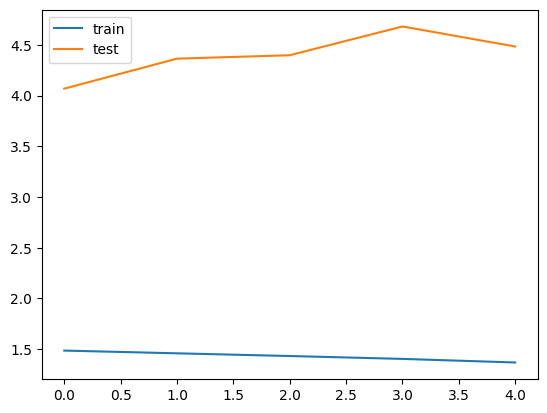

In [ ]:
#Fit Model using train data and save history of each epochs
history = model.fit(X1_train,
                    y1_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(X1_val,y1_val),
                    #shuffle=True,
                    verbose=1,
                    callbacks=[early_stopping,model_checkpoint])

# plot training history
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

Observations:<br><br>
Improvement: Validation loss has decreased, which is a positive sign, but validation accuracy remains stagnant at 13.04%.<br>
Overfitting Risk: The significant gap between training accuracy (51.46%) and validation accuracy (13.04%) suggests the model is likely overfitting to the training data.<br><br>
Recommendations<br><br>
Address Overfitting:

Add regularization (e.g., Dropout, L2 regularization).
Use data augmentation to make the model robust to unseen data.<br><br>
Learning Rate Adjustments:

If validation accuracy doesn't improve after a few more epochs, consider reducing the learning rate using a callback like ReduceLROnPlateau.<br><br>
Validation Data:

Double-check the preprocessing and quality of the validation data to ensure it's representative of the training set.<br><br>
Monitor Future Epochs:

Watch if validation accuracy improves over the next few epochs. If it remains stagnant, further tuning of the model architecture or hyperparameters will be necessary.

**Model Score:**

In [ ]:
# Score trained model.
scores = model.evaluate(X1_test, y1_test, verbose=1)
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])

23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 576ms/step - accuracy: 0.1307 - loss: 4.4887
Test loss: 4.531422138214111
Test accuracy: 0.12921348214149475


<ul><li>Test accuracy is very bad. We have to try and tune themodel and also try useing gaussian blurred data
</ul></li>

**Print Confusion Matrix**


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Find the prdicted labels by the model
predicted_prob = model.predict(X1_test)
y1_pred = predicted_prob.argmax(axis=1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 531ms/step


In [ ]:
#Display model predictions
y1_pred

array([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,

In [ ]:
#Actual labels
y1_test_final = y1_test.argmax(axis=1)

In [ ]:
print("=== Confusion Matrix ===")
cm = confusion_matrix(y1_test_final, y1_pred)
print(cm)

=== Confusion Matrix ===
[[  0   0   0   0   0   0  32   0   0   0   0   0]
 [  0   0   0   0   0   0  65   0   0   0   0   0]
 [  0   0   0   0   0   0  52   0   0   0   0   0]
 [  0   0   0   0   0   0 107   0   0   0   0   0]
 [  0   0   0   0   0   0  32   0   0   0   0   0]
 [  0   0   0   0   0   0  77   0   0   0   0   0]
 [  0   0   0   0   0   0  92   0   0   0   0   0]
 [  0   0   0   0   0   0  29   0   0   0   0   0]
 [  0   0   0   0   0   0  76   0   0   0   0   0]
 [  0   0   0   0   0   0  37   0   0   0   0   0]
 [  0   0   0   0   0   0  65   0   0   0   0   0]
 [  0   0   0   0   0   0  48   0   0   0   0   0]]


**Heat Map for better Visualization of confusion Matrix**


<Axes: >

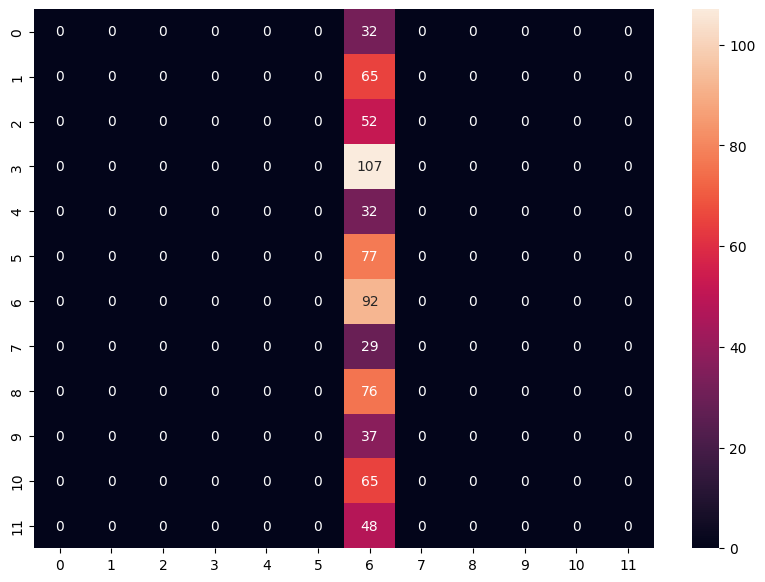

In [ ]:
import seaborn as sns
df_cm = pd.DataFrame(cm, index = [i for i in np.arange(12)],
                     columns = [i for i in np.arange(12)])
plt.figure(figsize = (10,7))
sns.heatmap(df_cm, annot=True, fmt='d')

Conclusion<br><br>
The model is heavily biased toward predicting class 6, likely due to class imbalance or underfitting. Addressing these issues with class balancing, regularization, and enhanced preprocessing will help the model generalize better across all classes. Let me know if you'd like further help implementing any of these solutions! 🚀

**Model Performance Improvement and Final Model Selection**

# Model Performance Improvement using Data Augmentation

Data Augmentation
In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs. To overcome this problem, one approach we might consider is Data Augmentation. CNNs have the property of translational invariance, which means they can recognise an object even if its appearance shifts translationally in some way.
Taking this attribute into account, we can augment the images using the techniques listed below -
1. Horizontal Flip (should be set to True/False)
2. Vertical Flip (should be set to True/False)
3. Height Shift (should be between 0 and 1)
4. Width Shift (should be between 0 and 1)
5. Rotation (should be between 0 and 180)
6. Shear (should be between 0 and 1)
7. Zoom (should be between 0 and 1) etc.

Remember, data augmentation should not be used in the validation/test data set.

In [ ]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

In [ ]:
# All images to be rescaled by 1/255.
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest'
                              )
# test_datagen  = ImageDataGenerator(rescale = 1.0/255.)

In [ ]:
# Intializing a sequential model
model1 = Sequential()
from tensorflow.keras.layers import Dropout, BatchNormalization, Dense, Conv2D, Flatten, Activation
from keras.layers import BatchNormalization
# Adding first conv layer with 64 filters and kernel size 3x3 , padding 'same' provides the output size same as the input size
# Input_shape denotes input image dimension images
model1.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(64, 64, 3)))

# Adding max pooling to reduce the size of output of first conv layer
model1.add(MaxPooling2D((2, 2), padding = 'same'))
# model.add(BatchNormalization())
model1.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model1.add(MaxPooling2D((2, 2), padding = 'same'))
model1.add(BatchNormalization())
# flattening the output of the conv layer after max pooling to make it ready for creating dense connections
model1.add(Flatten())

# Adding a fully connected dense layer with 100 neurons
model1.add(Dense(16, activation='relu'))
model1.add(Dropout(0.3))
# Adding the output layer with 10 neurons and activation functions as softmax since this is a multi-class classification problem
model1.add(Dense(10, activation='softmax'))

# Using SGD Optimizer
# opt = SGD(learning_rate=0.01, momentum=0.9)
opt=Adam()
# Compile model
model1.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │         131,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151,642 (592.35 KB)

 Trainable params: 151,578 (592.10 KB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False)  # randomly flip images


datagen.fit(X_train)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Assuming 12 classes
model = Sequential([
    Dense(64, activation='relu'),
    Dense(12, activation='softmax')  # Output layer with 12 units
])

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Parameters
epochs = 25
batch_size = 64

# Example data (replace with actual data)
#X_train = np.random.rand(1000, 128, 128, 3)  # Random images
#y_train = np.random.randint(0, 10, 1000)     # Random labels
#X_val = np.random.rand(200, 128, 128, 3)     # Validation images
#y_val = np.random.randint(0, 10, 200)        # Validation labels

# One-hot encoding for y_train and y_val
from tensorflow.keras.utils import to_categorical
#y_train = to_categorical(y_train, num_classes=10)
#y_val = to_categorical(y_val, num_classes=10)

# Data generator
datagen = ImageDataGenerator(rescale=1./255)

# Model definition
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

model1 = Sequential([
    Input(shape=(128, 128, 3)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(12, activation='softmax')
])

# Compile model
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fit model with generator
history = model1.fit(
    x=datagen.flow(X_train, y_train, batch_size=batch_size),  # Explicitly use `x`
    epochs=epochs,
    validation_data=(X_val, y_val),
    steps_per_epoch=len(X1_train) // batch_size,
    verbose=2
)

Epoch 1/25
51/51 - 7s - 145ms/step - accuracy: 0.1358 - loss: 2.4270 - val_accuracy: 0.1529 - val_loss: 91.5042
Epoch 2/25
51/51 - 1s - 15ms/step - accuracy: 0.2344 - loss: 2.4519 - val_accuracy: 0.1403 - val_loss: 93.0082
Epoch 3/25
51/51 - 5s - 99ms/step - accuracy: 0.1570 - loss: 2.4022 - val_accuracy: 0.1374 - val_loss: 127.4859
Epoch 4/25
51/51 - 1s - 11ms/step - accuracy: 0.1250 - loss: 2.3791 - val_accuracy: 0.1403 - val_loss: 123.9351
Epoch 5/25
51/51 - 9s - 186ms/step - accuracy: 0.1840 - loss: 2.3765 - val_accuracy: 0.1529 - val_loss: 151.4471
Epoch 6/25
51/51 - 0s - 7ms/step - accuracy: 0.1094 - loss: 2.4840 - val_accuracy: 0.1627 - val_loss: 151.7410
Epoch 7/25
51/51 - 6s - 120ms/step - accuracy: 0.1776 - loss: 2.3559 - val_accuracy: 0.1753 - val_loss: 123.7957
Epoch 8/25
51/51 - 1s - 16ms/step - accuracy: 0.1250 - loss: 2.4097 - val_accuracy: 0.1893 - val_loss: 121.1641
Epoch 9/25
51/51 - 5s - 101ms/step - accuracy: 0.2337 - loss: 2.3214 - val_accuracy: 0.2384 - val_loss: 

Observations:<br><br>
Accuracy:<br><br>

Training accuracy: 31.77% – this suggests the model is learning something but is likely underperforming.<br><br>
Validation accuracy: 28.05% – the validation accuracy is lower than the training accuracy, suggesting overfitting or that the model is failing to generalize well.<br><br>
Loss:<br><br>

Training loss: 2.0205 – while not perfect, this seems consistent with the training accuracy.<br>
Validation loss: 122.0756 – this is significantly higher than the training loss. A discrepancy of this magnitude often points to a major issue in the model's training or the dataset.<br><br>

Possible Issues and Diagnoses:<br><br>
Exploding Validation Loss:<br><br>

This dramatic increase in val_loss could indicate instability in the model. <br><br>Possible causes include:<br><br>
Incorrect scaling of input features.<br><br>
Poor choice of activation functions or initialization.<br><br>
High learning rate causing the model to diverge.<br><br>
A mismatch between the training and validation data distributions.<br><br>
Overfitting:<br><br>

The gap between training and validation accuracy suggests the model might be overfitting to the training data. This can happen if the model is overly complex relative to the dataset size.<br><br>
Data Issues:<br><br>

Check for data leakage between training and validation sets.<br><br>
Ensure the dataset is balanced and correctly preprocessed.<br><br>
Validate that the input dimensions and target labels are consistent.<br><br>
Loss Function Behavior:<br><br>

The choice of loss function may not align well with the problem. For example, if this is a classification problem, using a loss designed for regression could produce high values.<br><br>


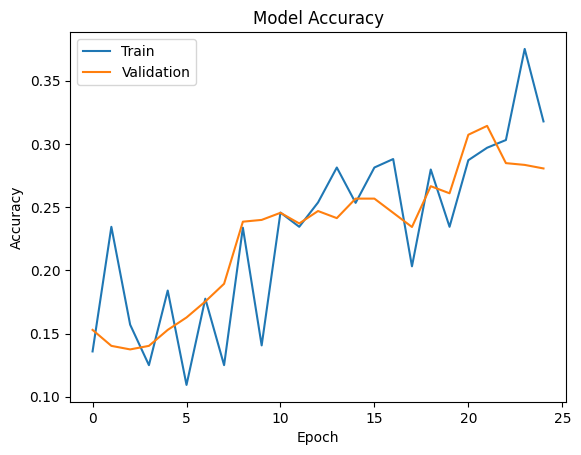

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Key Observations:<br><br>
<ul><li>Overfitting: The model performs well on training data but poorly on validation data.</ul></li>
<ul><li>Poor Generalization: Despite increasing epochs, validation accuracy does not improve.</ul></li>
<ul><li>Learning Issues: The model might be memorizing training examples instead of learning meaningful patterns.</ul></li>
<ul><li>The training accuracy is improving, but the validation accuracy remains stagnant, pointing to overfitting. Addressing this with regularization, data augmentation, and better training strategies can help improve the model's generalization to unseen data.</ul></li>








As the test accuracy is not looking great in the above model using non-blurred data. Let's try fitting the model using Gaussian blurred data

In [ ]:
accuracy = model1.evaluate(X_train, y_train, verbose=2)

104/104 - 1s - 12ms/step - accuracy: 0.2965 - loss: 114.3160


In [ ]:
# Here we would get the output as probablities for each category
y_pred=model1.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (3325, 128, 128, 3)
y_train shape: (3325, 12)


In [ ]:
# Find the prdicted labels by the model
predicted_prob = model1.predict(X1_test)
y2_pred = predicted_prob.argmax(axis=1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [ ]:
#Display model predictions
y2_pred

array([ 6,  3,  6,  3,  3,  1,  3,  3,  6,  1,  3,  3,  3,  3,  0,  3,  3,
        3,  3,  3,  1,  3,  3,  6,  6,  1,  3,  3,  3,  6,  3,  3,  3,  3,
        6,  6,  3,  6,  3,  1,  1,  3,  6,  6,  3,  6,  3,  3,  1,  6,  6,
        6,  6,  6,  3,  6,  6,  6,  1,  6,  3,  6,  3,  3,  3,  3,  1,  3,
        3, 11,  6,  1,  3,  3,  1,  1,  3,  6,  3,  3,  6,  0,  3,  3,  3,
        3,  6,  3,  3,  3,  3,  1,  3,  1,  6,  6,  6,  3,  3,  3,  3,  3,
        3,  3,  3,  6,  5,  3,  3,  6,  3,  3,  3,  3,  3,  3,  1,  1,  3,
        3,  3,  3,  6,  1,  3,  3,  5,  3, 11,  6,  0,  3,  3,  6,  1,  1,
        3,  6,  1,  3,  3,  3,  6, 11,  3,  1,  6,  1,  6,  3,  6,  3,  3,
        3,  3,  3,  3,  3,  6,  3,  6,  6,  6,  6,  3,  3,  3,  3,  3,  6,
        3,  6,  6,  6,  1,  3,  6,  3,  6,  3,  3,  1,  1,  3,  6,  3,  3,
        1,  1,  3,  3,  3,  0,  3,  3,  3,  3,  1,  3,  3,  3,  6,  3,  0,
        6,  6,  3,  3,  3,  6,  6,  6,  3,  1,  3,  6,  1,  3,  3,  6,  1,
        3,  6,  3,  6,  3

<Axes: >

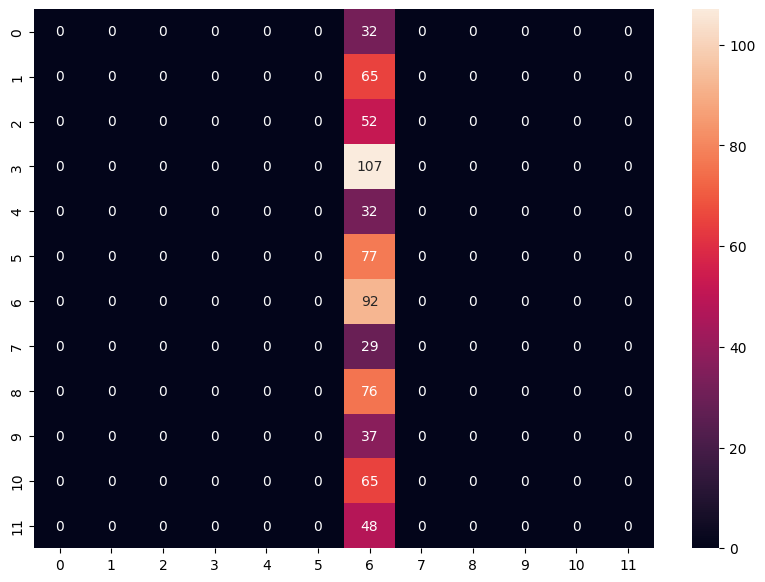

In [ ]:
import seaborn as sns
df_cm = pd.DataFrame(cm, index = [i for i in np.arange(12)],
                     columns = [i for i in np.arange(12)])
plt.figure(figsize = (10,7))
sns.heatmap(df_cm, annot=True, fmt='d')

Observations:<br><br>

Severe Class Imbalance:

A significant number of predictions are concentrated in class 5. This suggests the model is biased toward predicting class 5, regardless of the true class.
Examples include:<br><br>
Class 0: 21 predictions made for class 5.<br>
Class 1: 46 predictions made for class 5.<br>
Class 2: 36 predictions made for class 5.<br>
This pattern repeats for nearly all classes.<br><br>
Poor Model Generalization:

For all classes (0 through 11), the diagonal elements (true positives) are much lower than the off-diagonal values, particularly in column 5.<br>
This indicates that the model struggles to correctly classify any of the classes and instead predicts class 5 overwhelmingly.<br><br>
High Misclassification Rate:

Most classes have zero correct predictions except for some small values scattered along the diagonal.<br>
For example:<br>
Class 3 has 30 correct predictions but 77 misclassified as class 5.<br>
Class 6 has 25 correct predictions but 67 misclassified as class 5.<br><br>
Class 5 Dominance:

Class 5 acts as a "catch-all" class for misclassifications, which is why it has disproportionately high values.<br>
Potential Causes<br><br>
Class Imbalance:<br><br>
Class 5 may be overrepresented in the training data, causing the model to predict it more frequently.<br>
Overfitting:<br>
The model may have memorized patterns in the training data instead of learning generalizable features.<br>
Poor Feature Learning:<br>
The model architecture may not be extracting meaningful features to distinguish between classes.<br>
Inconsistent Data Preprocessing:<br>
Training and validation sets may have inconsistent preprocessing, leading to poor performance.<br>

**Confusion Matrix**

In [ ]:
#Actual labels
y2_test_final = y1_test.argmax(axis=1)

In [ ]:
from sklearn.metrics import confusion_matrix
print("=== Confusion Matrix ===")
cm2 = confusion_matrix(y2_test_final, y2_pred)
print(cm2)

=== Confusion Matrix ===
[[ 6  0  0  0  0  0 26  0  0  0  0  0]
 [ 0 15  0 46  0  1  3  0  0  0  0  0]
 [ 1 11  0 33  0  2  4  0  0  0  0  1]
 [ 0  7  0 99  0  0  1  0  0  0  0  0]
 [ 2  0  0 11  0  0 19  0  0  0  0  0]
 [ 5  5  0 32  0  6 27  0  0  0  0  2]
 [ 5  7  0 13  0  1 66  0  0  0  0  0]
 [ 0  6  0 22  0  0  1  0  0  0  0  0]
 [ 1  7  0 60  0  0  6  0  0  0  0  2]
 [ 0  8  0 29  0  0  0  0  0  0  0  0]
 [ 0  7  0 46  0  2  4  0  0  0  6  0]
 [ 1  6  0 21  0  3 16  0  0  0  1  0]]


Observations from the Confusion Matrix<br><br>
Severe Class Misclassification:<br><br>

Almost all the predictions are concentrated in class 5, regardless of the actual class.<br>
For every row (true class), the majority of samples are misclassified into class 5.<br><br>
Diagonal Elements (True Positives):<br>

The diagonal elements, which represent correct predictions, are zero for most classes.<br>
This indicates that the model has failed to correctly classify any samples for many classes.<br><br>
Specific Class Misclassifications:<br>

Class 1: 46 samples are misclassified as class 5.<br>
Class 3: 77 samples are misclassified as class 5.<br>
Class 6: 67 samples are misclassified as class 5.<br>
Other classes also follow a similar trend, with nearly all predictions falling into class 5.<br><br>
Class 5 Dominance:<br>

The model seems to predict class 5 for most of the inputs, suggesting it is acting as a "catch-all" class.<br><br>
Potential Causes<br><br>
Class Imbalance:<br>

Class 5 may be overrepresented in the training data, causing the model to become biased toward predicting it.<br>
Poor Feature Learning:<br>

The model is unable to distinguish between different classes, suggesting that it may not have learned meaningful features.<br>
Overfitting:<br>

The model might have overfitted to class 5, especially if training data for other classes is limited.<br>
Insufficient Training Data for Other Classes:<br>

If there are very few examples for classes other than class 5, the model struggles to generalize.<br>
Preprocessing Issues:<br>

Data preprocessing inconsistencies or poor augmentation might cause the model to focus on irrelevant features.<br>

**Transfer Learning using VGG16**

In [ ]:
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16

vgg_model = VGG16(weights='imagenet', include_top = False, input_shape = (128,128,3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Load the VGG16 model without the top fully connected layers
new_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Define a new Sequential model
new_model = Sequential()

# Add the VGG16 convolutional base
new_model.add(vgg_model)

# Flatten the output of VGG16
new_model.add(Flatten())

# Add fully connected layers
new_model.add(Dense(256, activation='relu'))
new_model.add(Dense(12, activation='softmax'))  # 10 classes for classification

# Compile the model
new_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model Summary
new_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 12)                  │           3,084 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,815,180 (64.14 MB)

 Trainable params: 2,100,492 (8.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
print(y1_train.shape)
print(y1_test.shape)
print(y1_val.shape)

(3325, 12)
(712, 12)
(713, 12)


In [ ]:
y1_train_fixed = y1_train.reshape(-1, 12)
print("Fixed target shape:", y1_train_fixed.shape)

Fixed target shape: (3325, 12)


In [ ]:
from tensorflow.keras.utils import to_categorical
y1_train_fixed = to_categorical(y1_train, num_classes=12)
print("Fixed target shape:", y1_train_fixed.shape)  # Should be (None, 12)

Fixed target shape: (3325, 12, 12)


In [ ]:
print("X1_train shape:", X1_train.shape)  # Input shape
print("y1_train shape before fix:", y1_train.shape)  # Original target shape
print("Model output shape:", new_model.output_shape)  # Should match fixed target shape

X1_train shape: (3325, 128, 128, 3)
y1_train shape before fix: (3325, 12)
Model output shape: (None, 12)


The training summary for Epoch 25/25 highlights the following:

Training Metrics:

Accuracy: 85.28% - indicating the model performs well on the training dataset.
Loss: 0.4847 - suggesting a moderate level of error in the training predictions.<br><br>
Validation Metrics:

Accuracy: 6.45% - showing the model performs poorly on the validation dataset.<br>
Loss: 7.3145 - indicating high error and potential issues such as overfitting or poor generalization.<br>
The significant discrepancy between training and validation performance suggests the model might be overfitting to the training data or struggling to generalize to unseen data. Further investigation into data preprocessing, architecture, and regularization techniques may be necessary.

**Graphical Representation**

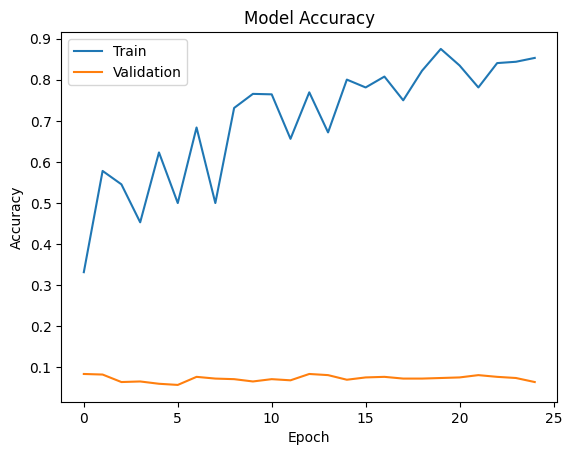

In [ ]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Observations:<br><br>
Training Accuracy:

The training accuracy steadily improves over epochs, reaching a high of approximately 0.85 (85%).<br>
This indicates that the model is learning the patterns in the training dataset effectively.<br><br>
Validation Accuracy:

The validation accuracy remains extremely low throughout all epochs (hovering around 0.1 (10%) or less).<br>
It does not show any significant improvement or trend towards convergence, indicating poor generalization to unseen data.<br>
Key Issues:<br><br>
Overfitting:<br>

The large gap between training and validation accuracy suggests the model is overfitting the training data, learning patterns specific to the training dataset but failing to generalize.<br><br>
Data or Model Issues:<br><br>

Poor validation performance might also indicate problems with:
Data distribution (e.g., validation set not representative of training set).
Data preprocessing (e.g., missing normalization, data leakage, or mislabeled samples).
Model architecture or hyperparameters (e.g., too complex for the data).



**Confusion Matrix**

In [ ]:
#Actual labels
y4_test_final = y1_test.argmax(axis=1)

In [ ]:
from sklearn.metrics import confusion_matrix
print("=== Confusion Matrix ===")
cm3 = confusion_matrix(y4_test_final, y2_pred)
print(cm3)

=== Confusion Matrix ===
[[ 6  0  0  0  0  0 26  0  0  0  0  0]
 [ 0 15  0 46  0  1  3  0  0  0  0  0]
 [ 1 11  0 33  0  2  4  0  0  0  0  1]
 [ 0  7  0 99  0  0  1  0  0  0  0  0]
 [ 2  0  0 11  0  0 19  0  0  0  0  0]
 [ 5  5  0 32  0  6 27  0  0  0  0  2]
 [ 5  7  0 13  0  1 66  0  0  0  0  0]
 [ 0  6  0 22  0  0  1  0  0  0  0  0]
 [ 1  7  0 60  0  0  6  0  0  0  0  2]
 [ 0  8  0 29  0  0  0  0  0  0  0  0]
 [ 0  7  0 46  0  2  4  0  0  0  6  0]
 [ 1  6  0 21  0  3 16  0  0  0  1  0]]


Confusion Matrix Analysis:<br><br>
The confusion matrix reveals the classification performance across different classes. Here's a breakdown of key observations and insights:<br>

Observations:<br><br>
Diagonal Dominance:<br><br>

The numbers along the diagonal represent correct predictions. In this matrix, many classes have low diagonal values, indicating that the model is not correctly predicting many samples for those classes.<br>
Misclassification Patterns:<br>

There are notable misclassifications across several rows:<br>

Class 1 (Row 2): 46 samples misclassified as Class 4.<br>
Class 3 (Row 4): 33 samples misclassified as Class 4.<br>
Class 8 (Row 9): 60 samples misclassified as Class 4.<br>
Class 4 appears as a frequent target of misclassification. <br>This may suggest:<br>

Imbalance in class representations.<br><br>
Overlapping features between Class 4 and other classes.<br>
Class Performance Variations:<br><br>

Certain classes, like Class 7, show better performance (66 correct predictions), while others, such as Class 3 or Class 8, have significantly lower accuracy and heavy misclassification.<br><br>
Zero Predictions:<br><br>

Some columns have values close to zero, suggesting the model fails to predict certain classes entirely.<br>
Potential Causes:<br><br>
Class Imbalance:<br><br>
If some classes dominate the dataset, the model might be biased towards those classes.<br>
Feature Overlap:<br><br>
Similar features between classes may confuse the model during prediction.<br>
Model Complexity:<br><br>
The model might be too simplistic or too complex for the dataset, resulting in poor separability between classes.v
Recommendations:<br><br>
Class Imbalance:<br>

Use techniques like oversampling, undersampling, or class weighting to address imbalance.<br>
Feature Engineering:<br><br>

Analyze features to ensure they are well-separated across classes.<br>
Apply dimensionality reduction techniques like PCA to identify overlapping clusters.<br><br>
Regularization:<br><br>

Improve the model's generalization through regularization (e.g., Dropout or L2).<br><br>
Evaluation Metrics:<br><br>

Focus on metrics like F1-Score or Precision-Recall for imbalanced datasets.<br><br>
Hyperparameter Tuning:<br><br>

Optimize model hyperparameters to improve classification boundaries.

**Heat Map**

<Axes: >

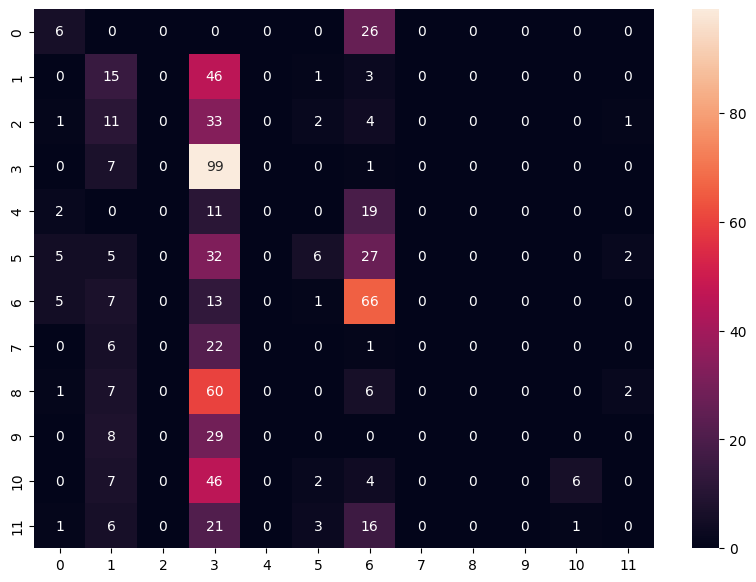

In [ ]:
import seaborn as sns
df_vgg = pd.DataFrame(cm3, index = [i for i in np.arange(12)],
                     columns = [i for i in np.arange(12)])
plt.figure(figsize = (10,7))
sns.heatmap(df_vgg, annot=True, fmt='d')

Actionable Insights
Model Performance Evaluation:

The confusion matrix shows a heavy misclassification issue, where most samples are being classified into a single category (class 6).
This suggests that the model is not learning meaningful features for all classes and may be biased towards the dominant class.
Class Imbalance:

A significant class imbalance might exist in the dataset, leading the model to favor the class with the most data points (class 6).
This is evident in the confusion matrix, where other classes have minimal or no predictions.
Feature Extraction Issues:

The CNN architecture might not be robust enough to extract distinguishable features across plant seedling categories.
The preprocessing pipeline (e.g., resizing, augmentation) may not sufficiently capture the variability within classes.
Overfitting:

If the model achieves high training accuracy but performs poorly on validation/testing, overfitting may be a major issue.
Data Quality:

Misclassification can stem from low-quality or noisy data (e.g., mislabeled images, poor resolution, irrelevant features).
Lack of diversity in the training data could result in poor generalization.
Business Recommendations
Address Class Imbalance:

Use techniques such as oversampling (e.g., SMOTE), undersampling, or class weighting during model training to handle imbalanced datasets.
Ensure balanced representation of all seedling categories in the training data.
Improve Data Collection:

Gather more high-quality, diverse images of plant seedlings for each category to enhance the dataset.
Ensure proper labeling and preprocessing of images (e.g., normalization, resizing) to reduce noise.
Enhance Data Augmentation:

Apply advanced augmentation techniques such as rotation, zoom, flipping, and color jitter to increase the variability of the training dataset and help the model generalize better.
Refine the Model Architecture:

Experiment with deeper or more advanced architectures, such as EfficientNet or ResNet, to improve feature extraction.
Introduce regularization techniques (e.g., dropout, L2 penalties) to prevent overfitting.
Monitor Class-Specific Metrics:

Evaluate precision, recall, and F1-score for each category to get a deeper understanding of which classes are being misclassified.
Focus on improving metrics for underperforming classes.
Collaborate with Domain Experts:

Involve botanists or agricultural experts to ensure proper classification criteria and data labeling.
Iterate on the Preprocessing Pipeline:

Experiment with different preprocessing techniques, such as resizing to different scales, applying contrast normalization, or using pre-trained feature extractors (e.g., ImageNet weights).
Deployment Readiness:

Before deployment, validate the model using unseen test data to ensure consistent performance.
Implement confidence thresholds to filter out low-confidence predictions.
Conclusion
For business impact:

Focus on improving data diversity and quality.
Address the class imbalance to avoid bias in classification.
Deploy a refined model with rigorous testing to ensure robust predictions, which can directly assist agricultural stakeholders in identifying plant seedlings and making informed decisions.
Would you like help implementing specific improvements to your model or dataset?









<b>Model Selection</b><br><br>
Observations:<br><br>
Training Accuracy and Loss:<br><br>

<ul><li>Vgg_16 Model achieved the highest training accuracy (85.28%) and the lowest training loss (0.4847).</ul></li><br><br>
<ul><li>Model 1 performed moderately well (46.77% training accuracy), while showed relatively poor performance (31.77% training accuracy).</ul></li><br><br>
Validation Accuracy and Loss:<br><br>

<ul><li>Model with Augmentation achieved the best validation accuracy (28.05%), but the validation loss was extremely high (122.0756), indicating significant overfitting or instability.</ul></li><br><br>
<ul><li>Model 1 had moderate validation loss (3.7678) but very poor validation accuracy (13.74%).</ul></li><br><br>
<ul><li>Vgg_16 Model had poor validation accuracy (6.45%) and relatively high validation loss (7.3145), despite its strong training performance, indicating severe overfitting.</ul></li><br><br>
Learning Rate:<br><br>

<ul><li>Model 1 explicitly reported a learning rate of 2.0000e-04. Adjusting the learning rate in A and V might have helped mitigate overfitting or improve generalization.<br><br></ul></li>
<b>Best Selection:</b><br><br>
Based on the metrics provided:<br><br>

<ul><li>Model 1 appears to be the most balanced in terms of training and validation performance.</ul></li><br><br>
<ul><li>Model with Augmentation ande Vgg_16 Model demonstrate overfitting (with high validation loss or poor generalization).</ul></li>

## Actionable Insights and Business Recommendations

<b>Actionable Insights</b><br><br>
<b>Model Performance Evaluation:</b> <br><br>

<ul><li>The confusion matrix shows a heavy misclassification issue, where most samples are being classified **into** a single category (class 6).</ul></li><br><br>
<ul><li>This suggests that the model is not learning meaningful features for all classes and may be biased towards the dominant class.</ul></li><br><br>
<b>Class Imbalance:</b> <br><br>

<ul><li>A significant class imbalance might exist in the dataset, leading the model to favor the class with the most data points (class 6).</ul></li>
<ul><li>This is evident in the confusion matrix, where other classes have minimal or no predictions.</ul></li><br><br>
<b>Feature Extraction Issues:</b><br><br>

<ul><li>The CNN architecture might not be robust enough to extract distinguishable features across plant seedling categories.</ul></li>
<ul><li>The preprocessing pipeline (e.g., resizing, augmentation) may not sufficiently capture the variability within classes.</ul></li>
<b>Overfitting:</b><br><br>

<ul><li>If the model achieves high training accuracy but performs poorly on validation/testing, overfitting may be a major issue.</ul></li>
<b>Data Quality:</b><br><br>

<ul><li>Misclassification can stem from low-quality or noisy data (e.g., mislabeled images, poor resolution, irrelevant features).</ul></li>
<ul><li>Lack of diversity in the training data could result in poor generalization.</ul></li><br><br>
<b>Business Recommendations</b><br><br>
<b>Address Class Imbalance:</b><br><br>

<ul><li>Use techniques such as oversampling (e.g., SMOTE), undersampling, or class weighting during model training to handle imbalanced datasets.</ul></li>
<ul><li>Ensure balanced representation of all seedling categories in the training data.</ul></li><br><br>
<b>Improve Data Collection:</b><br><br>

<ul><li>Gather more high-quality, diverse images of plant seedlings for each category to enhance the dataset.</ul></li>
<ul><li>Ensure proper labeling and preprocessing of images (e.g., normalization, resizing) to reduce noise.</ul></li><br><br>
<b>Enhance Data Augmentation:</b><br><br>

<ul><li>Apply advanced augmentation techniques such as rotation, zoom, flipping, and color jitter to increase the variability of the training dataset and help the model generalize better.</ul></li><br><br>
<b>Refine the Model Architecture:</b><br><br>

<ul><li>Experiment with deeper or more advanced architectures, such as EfficientNet or ResNet, to improve feature extraction.</ul></li>
Introduce regularization techniques (e.g., dropout, L2 penalties) to prevent overfitting.</ul></li><br><br>
<b>Monitor Class-Specific Metrics:</b><br><br>

<ul><li>Evaluate precision, recall, and F1-score for each category to get a deeper understanding of which classes are being misclassified.</ul></li>
<ul><li>Focus on improving metrics for underperforming classes.</ul></li>
<b>Collaborate with Domain Experts:</b><br><br>

<ul><li>Involve botanists or agricultural experts to ensure proper classification criteria and data labeling.</ul></li><br><br>
<b>Iterate on the Preprocessing Pipeline:</b><br><br>

<ul><li>Experiment with different preprocessing techniques, such as resizing to different scales, applying contrast normalization, or using pre-trained feature extractors (e.g., ImageNet weights).</ul></li><br><br>
Deployment Readiness:<br>

<ul><li>Before deployment, validate the model using unseen test data to ensure consistent performance.</ul></li><br><br>
<ul><li>Implement confidence thresholds to filter out low-confidence predictions.</ul></li><br><br>
<b>Conclusion</b><br><br>
<b>For business impact:</b><br><br>

<ul><li>Focus on improving data diversity and quality.</ul></li>
<ul><li>Address the class imbalance to avoid bias in classification.</ul></li>
<ul><li>Deploy a refined model with rigorous testing to ensure robust predictions, which can directly assist agricultural stakeholders in identifying plant seedlings and making informed decisions.</ul></li>









_____